# Multi-Target Contact Follower Simulation

In this notebook, we'll build and run a system that tackles a classic tracking challenge: following multiple underwater acoustic sources.

### Simulation Steps:
1.  **Generate Ground Truth**: We'll start by creating the perfect, error-free paths of our underwater targets and the sensor platform.
2.  **Simulate Acoustic Signals**: Next, we'll model how sound propagates through the water from the sources to the sensor array.
3.  **Process and Detect Contacts**: We'll then use a beamforming algorithm to create a Signal-to-Noise Ratio (SNR) map and detect potential targets.
4.  **Track the Targets**: Using the detections, we'll initialise and run a Kalman filter with JPDA to estimate each target's path.
5.  **Visualise the Results**: Finally, we'll plot the ground truth, detections, and estimated tracks to see how well our tracker performed.

Let's begin by importing the necessary libraries.

In [91]:
# --- Python Standard Libraries ---
import os
from dataclasses import dataclass, field
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt

# --- Third-Party Libraries ---
import numpy as np
from scipy.signal.windows import get_window
from tqdm.notebook import tqdm

# --- Core TrackBox Components ---
from nereus.association.hypothesisers import JPDAHypothesiser
from nereus.filters.predictors import KalmanPredictor
from nereus.filters.updaters import GaussianMixtureKalmanUpdater
from nereus.models.measurement import LinearGaussianMeasurementModel
from nereus.models.propagation import (
    AcousticPropagationModel,
    SphericalAcousticPropagationModel,
)
from nereus.models.sensor import HorizontalLineArray
from nereus.models.signal import (
    AcousticSignalModel,
    ColouredNoise,
    NoiseModel,
)
from nereus.models.source import AcousticPointSource
from nereus.models.ssp import Munk, SoundSpeedProfile
from nereus.models.transition import (
    CombinedLinearGaussianTransitionModel,
    NearlyConstantVelocity,
)
from nereus.sigproc.beamformers import (
    DelayAndSumBeamformer,
    calculate_directional_power,
    calculate_steering_delays,
)
from nereus.sigproc.detectors import CFARDetector, PeakDetector
from nereus.trackers import MultiTargetTracker
from nereus.types.arrays import StateVector, StateVectors
from nereus.types.detections import TrueDetection
from nereus.types.states import (
    GaussianState,
    GroundTruthPath,
    GroundTruthState,
    Track,
)
from nereus.utils.functions import (
    cartesian_to_bearing_state,
    p_d_rayleigh,
    p_fa_from_snr_thresh,
)
from nereus.utils.plotting import BearingsPlotter

%matplotlib inline

In [92]:
root_dir = Path(os.getcwd()).parent
nereus_dir = root_dir / "nereus"
print(f"nereus directory: {nereus_dir}")

nereus directory: f:\Coding\Projects\Nereus\nereus


In [93]:
# Enable the autoreload extension
%load_ext autoreload

# Configure it to automatically reload all modules before executing a cell
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Simulation Configuration

To keep our simulation organised and easily adjustable, we'll define a `Config` class. This class will act as a central hub for all the parameters of our scenario.

The main `Config` object is built from these specialised configuration classes:

* **`TimeConfig`**: Manages the simulation's timeline, including start time, duration, and time steps.
* **`SourceConfig`**: Defines the characteristics of each acoustic source (target), such as its initial state, depth, and sound properties.
* **`PlatformConfig`**: Specifies the properties of the sensor array, including its geometry and any potential hardware imperfections.
* **`SignalConfig`**: Controls signal-related parameters, like signal duration, sampling rate, and ambient noise levels.
* **`BeamformingConfig`**: Contains all the settings for our beamforming algorithm.
* **`DetectionConfig`**: Holds the thresholds and parameters for the contact detection process.
* **`FilterConfig`**: Specifies the settings for the tracker's Kalman filter, including noise parameters and gating thresholds.

In this notebook, we'll define a specific scenario with two targets directly within the `Config` class, making this a complete, self-contained example.

In [ ]:
@dataclass
class TimeConfig:
    """Parameters for simulation time."""

    # The simulation's starting timestamp.
    start_time: datetime = field(
        default_factory=lambda: datetime.now().replace(
            hour=0,
            minute=0,
            second=0,
            microsecond=0,
        )
    )
    # The duration between each consecutive step of the simulation.
    time_interval: timedelta = timedelta(seconds=10)
    # The total number of discrete time steps to run in the simulation.
    num_steps: int = 180
    # A list of all discrete timestamps in the simulation.
    timesteps: list[datetime] = field(init=False)

    def __post_init__(self):
        """Calculate the list of timestamps after the object has been created."""
        self.timesteps = [
            self.start_time + i * self.time_interval
            for i in range(self.num_steps)
        ]


@dataclass
class SourceConfig:
    """Parameters for a single acoustic source (target)."""

    # A human-readable name for the target, used for plotting and logging.
    label: str
    # The initial state vector of the target: [x_pos, x_vel, y_pos, y_vel].
    initial_state: list[float]
    # The depth of the target in meters (z-coordinate). This parameter is excluded from
    # the state vector as we will assume all targets are at the same depth, but it is
    # still important for sound propagation.
    z_pos: float
    # A list of source levels for each tonal frequency emitted by the target, in
    # decibels (dB).
    source_level_db: list[float]
    # A list of tonal frequencies emitted by the target, in Hertz (Hz).
    frequency_hz: list[float]
    # A list of initial phases for each tonal frequency, in degrees.
    phase_deg: list[float]
    # The variance of the noise in the target's motion model, representing path
    # randomness.
    process_noise_std: float

    def __post_init__(self):
        """Convert the phase from degrees to radians for internal consistency."""
        self.phase_rad = np.deg2rad(self.phase_deg)

@dataclass
class PlatformConfig:
    """Parameters for the sensor platform (array)."""

    # The total number of hydrophones (sensors) in the array.
    num_sensors: int = 1000
    # The distance between adjacent sensors, in meters.
    spacing_m: float = 1.0
    # The [x, y, z] Cartesian coordinates of the very first sensor in the array.
    position: list[float] = field(default_factory=lambda: [0, 0, -1000])
    # The standard deviation of the error in each sensor's physical position.
    position_error_std: float = 0.2
    # The standard deviation of the error in the gain of each sensor.
    gain_error_std: float = 0.05
    # The standard deviation of the error in the phase response of each sensor, in
    # radians.
    phase_error_std_rad: float = np.deg2rad(2)
    # The expected processing gain from the array in dB.
    array_gain: float = 30.0

@dataclass
class SignalConfig:
    """Parameters for signal propagation and noise."""

    # The acoustic propagation model used to simulate sound propagation in the water
    # column.
    propagator: AcousticPropagationModel = SphericalAcousticPropagationModel
    # The profile used to model the sound speed of the water column.
    ssp: SoundSpeedProfile = Munk
    # The depth of the ocean in meters, used to define the propagation environment.
    ocean_depth_m: float = 5000.0
    # The duration of each signal snapshot processed at each time step, in seconds.
    duration_s: float = 1.0
    # The sampling rate used to digitize the acoustic signals, in Hertz (Hz).
    sampling_rate_hz: int = 500
    # The noise model used to generate ambient noise in the simulation.
    noise_model: NoiseModel = ColouredNoise
    # The spectral exponent of the noise model, which defines the noise's frequency
    # characteristics.
    noise_spectral_exponent: float = -1 # -1 for pink noise, 0 for white noise, etc.
    # The ambient background noise level in the simulation environment, in
    # decibels (dB).
    noise_level_db: float = 84.0

@dataclass
class BeamformingConfig:
    """Parameters for the beamforming process."""

    # The angular step size between adjacent beams, in degrees. Defines the beamformer's
    # resolution.
    resolution_deg: int = 1
    # The windowing function (e.g., "blackman", "hanning") applied to array elements to
    # reduce sidelobes.
    shading_window: str = "blackman"
    # The total angular sector to scan with the beamformer, in degrees (e.g., 180 for a
    # full broadside scan).
    azimuth_span_deg: int = 180
    # The domain in which the beamforming is performed, either "frequency" or "time".
    domain: str = "frequency"

@dataclass
class DetectionConfig:
    """Parameters for the detection algorithm."""

    # --- CFAR Detector Parameters ---
    # The number of guard cells to ignore on each side of the Cell Under Test (CUT).
    # This prevents the signal from leaking into the noise estimate.
    num_guard_cells: int = 2

    # The number of training cells on each side of the guard cells used to
    # estimate the local noise level.
    num_training_cells: int = 5

    # The scaling factor (alpha) used to set the detection threshold above the
    # estimated noise floor. This directly controls the false alarm rate.
    threshold_factor: float = 2.5

    # --- Peak Detector Parameters ---
    # The minimum required separation between two detected peaks, measured in "bins"
    # (i.e., number of beams).
    peak_distance_bins: int = 3

@dataclass
class FilterConfig:
    """Parameters for the Kalman filter and tracker."""

    # The initial uncertainty (covariance) for a new track state
    # [bearing, bearing_rate], in radians.
    init_cov_diag_rad: tuple[float, float] = (np.deg2rad(0.001), np.deg2rad(0.0001))
    # The filter's assumption of the target's motion randomness (process noise).
    process_noise_std: float = 0.01
    # The filter's assumption of the uncertainty (noise) of a single bearing
    # measurement, in radians.
    measurement_noise_rad: float = np.deg2rad(0.02)
    # The probability threshold for creating a validation gate to associate detections
    # with tracks.
    gate_probability: float = 0.95
    # The number of dimensions in the state vector (e.g., 2 for
    # [bearing, bearing_rate]).
    ndim_state: int = 2
    # The mapping from the state vector to the measurement vector.
    # e.g., [0] means the measurement corresponds to the state vector's first element.
    state_mapping: list[int] = field(default_factory=lambda: [0])

# --- Main Configuration Class ---

@dataclass
class Config:
    """A single, structured class to hold all simulation parameters."""

    # A seed for the random number generator to ensure the simulation is reproducible.
    seed: int = 1999

    # Composes the overall configuration from the specific dataclasses defined above.
    time: TimeConfig = field(default_factory=TimeConfig)
    platform: PlatformConfig = field(default_factory=PlatformConfig)
    signal: SignalConfig = field(default_factory=SignalConfig)
    beamforming: BeamformingConfig = field(default_factory=BeamformingConfig)
    detection: DetectionConfig = field(default_factory=DetectionConfig)
    filter: FilterConfig = field(default_factory=FilterConfig)

    # Defines the specific scenario by listing all sources (targets) to be simulated.
    sources: list[SourceConfig] = field(default_factory=lambda: [
        SourceConfig(
            label="Target 1",
            initial_state=[-10000, 10, 5000, 0],
            z_pos=-10.0,
            source_level_db=[122.0, 115.0, 118.0],
            frequency_hz=[97.0, 72.0, 50.0],
            phase_deg=[-112.0, -151.0, 86.0],
            process_noise_std=0.001,
        ),
        SourceConfig(
            label="Target 2",
            initial_state=[5000, -10, 40000, 0], # [x, vx, y, vy]
            z_pos=-10.0,
            source_level_db=[120.0, 138.0],
            frequency_hz=[250, 170],
            phase_deg=[15, 40],
            process_noise_std=0.001,
        ),
    ])


In [95]:
config = Config()

np.random.seed(config.seed)  # Set the random seed for reproducibility

## 2. Ground Truth Generation

The "ground truth" represents the perfect, error-free reality of our simulation. Our tracker's goal is to estimate this ground truth using only noisy measurements. In this section, we'll define functions to generate the true paths of our targets and the sensor platform over time.

#### Scenario Description

Our simulation features a static, horizontal line array of hydrophones. We'll be tracking two targets on linear paths. These paths are designed to create a classic tracking challenge: their bearings, as seen from the platform, will intersect and cross. This scenario will test our tracker's ability to maintain correct target identities when they are close in bearing.

In [96]:
def generate_ground_truth(config: Config) -> dict:
    """Generate ground truth paths for all sources based on the dataclass config."""
    # --- Platform Centre Calculation ---
    platform_conf = config.platform
    platform_center_x = (
        platform_conf.position[0]
        + ((platform_conf.num_sensors - 1) * platform_conf.spacing_m / 2.0)
    )
    platform_center_y = platform_conf.position[1]
    platform_center = StateVector([platform_center_x, 0, platform_center_y, 0])

    # --- Initialise Transition Models & Truth Lists ---
    transition_models = [
        NearlyConstantVelocity(
            src.process_noise_std, time_interval=config.time.time_interval
        )
        for src in config.sources
    ]
    combined_transition_model = CombinedLinearGaussianTransitionModel(
        transition_models
    )

    cartesian_truths = []
    bearing_truths = []
    source_truths = []

    # --- Initial State (t=0) ---
    for i, src in enumerate(config.sources):
        initial_cartesian_state = GroundTruthState(
            StateVector(src.initial_state),
            timestamp=config.time.start_time
        )
        cartesian_truths.append(GroundTruthPath([initial_cartesian_state], id=i))

        initial_relative_state = initial_cartesian_state.state_vector - platform_center
        initial_bearing_state = GroundTruthState(
            cartesian_to_bearing_state(initial_relative_state),
            timestamp=config.time.start_time
        )
        bearing_truths.append(GroundTruthPath([initial_bearing_state], id=i))

        source_truths.append(GroundTruthPath([], id=i))

    # --- Propagate States Over Time (t > 0) ---
    for i in range(1, config.time.num_steps):
        # Iterate through each truth path and transition its state individually.
        for idx, path in enumerate(cartesian_truths):
            # Get the last known state for the current target.
            last_state = path[-1]

            # Call the transition function for the single state object.
            new_state_vector = combined_transition_model.function(
                last_state,
                noise=True
            )

            # Append the new cartesian state to its path.
            new_cartesian_state = GroundTruthState(
                new_state_vector, timestamp=config.time.timesteps[i]
            )
            path.append(new_cartesian_state)

            # Calculate and append the new corresponding bearing state.
            relative_state = new_cartesian_state.state_vector - platform_center
            new_bearing_state = GroundTruthState(
                cartesian_to_bearing_state(relative_state),
                timestamp=config.time.timesteps[i]
            )
            bearing_truths[idx].append(new_bearing_state)

    # --- Generate Full Source Models ---
    for i, truth in enumerate(cartesian_truths):
        src_config = config.sources[i]
        for state in truth:
            source_state_vec = StateVector([
                state.state_vector[0], state.state_vector[2], src_config.z_pos
            ])
            source_truths[i].append(
                AcousticPointSource(
                    state_vector=source_state_vec,
                    amplitude=10 ** (
                        np.array(src_config.source_level_db) / 20
                    ),
                    frequency=src_config.frequency_hz,
                    phase_deg=src_config.phase_deg,
                    timestamp=state.timestamp,
                )
            )

    return {
        "bearing_truths": bearing_truths,
        "source_truths": source_truths,
    }


def generate_platform_truth(config: Config) -> GroundTruthPath:
    """Generate ground truth path for the sensor platform."""
    platform_conf = config.platform

    platform_state = StateVectors([
        StateVector([
            platform_conf.position[0] + i * platform_conf.spacing_m,
            platform_conf.position[1],
            platform_conf.position[2],
        ])
        for i in range(platform_conf.num_sensors)
    ])

    return GroundTruthPath([
        HorizontalLineArray(
            state_vector=platform_state,
            timestamp=ts,
            position_error_std=platform_conf.position_error_std,
            gain_error_std=platform_conf.gain_error_std,
            phase_error_std_rad=platform_conf.phase_error_std_rad,
        )
        for ts in config.time.timesteps
    ])

Now, let's visualise the ground truth trajectories in a bearing-time plot. This will give us a clear picture of the scenario our tracker will face, including the crossover point.

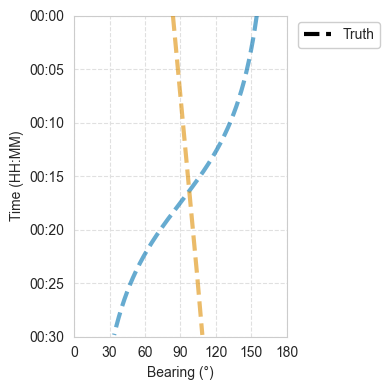

In [97]:
source_truths = generate_ground_truth(config)
platform_truth = generate_platform_truth(config)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide)

plotter.plot(
    source_truths['bearing_truths'],
    [],
    [],
    timesteps=config.time.timesteps,
    mapping=config.filter.state_mapping
)
plotter.show()

## 3. Simulating Signals and Generating Detections

With our ground truth established, it's time to simulate the detection process at each time step. This involves three key stages:

1.  **Acoustic Signal Generation**: We'll model the sound from each target as it travels through the water and is received by our 1000-sensor array. This simulation includes transmission loss and the addition of ambient background noise.
2.  **Beamforming**: A "Delay-and-Sum" beamformer will process the sensor signals to create a Signal-to-Noise Ratio (SNR) map, showing the acoustic energy from all possible directions.
3.  **Detection**: An algorithm scans the SNR map for peaks that exceed a defined threshold. These initial peaks are our raw "detections." However, due to spectral leakage, a single source can create multiple adjacent detections. To counteract this, we'll use a peak-finding algorithm to group these adjacent peaks and consolidate them into a single detection.

First, let's define the models for this stage.

In [98]:
models = {
    "propagation": config.signal.propagator(
        ssp=config.signal.ssp(),
    ),
    "signal_generator": AcousticSignalModel(),
    "noise_generator": ColouredNoise(
        spectral_exponent=config.signal.noise_spectral_exponent
    ),
    "beamformer": DelayAndSumBeamformer(
        sampling_frequency=config.signal.sampling_rate_hz,
        shading=get_window(
            config.beamforming.shading_window, config.platform.num_sensors
        ),
        domain=config.beamforming.domain,
    ),
    "cfar_detector": CFARDetector(
        num_guard_cells=config.detection.num_guard_cells,
        num_training_cells=config.detection.num_training_cells,
        threshold_factor=config.detection.threshold_factor,
        mode='wrap'  # Wrap mode to handle edge cases in the beamforming output
    ),
    "peak_detector": PeakDetector(distance=config.detection.peak_distance_bins),
    "measurement": LinearGaussianMeasurementModel(
        noise_covar=np.diag([config.filter.measurement_noise_rad**2]),
        mapping=config.filter.state_mapping,
        ndim_state=config.filter.ndim_state
    ),
}

#### 3.1 Signal Generation

We will now generate the received signals in three distinct parts:

1.  **Helper Function Definition (`generate_signal`)**
    We first define a helper function that contains all the logic for a single moment in time. For each timestep, this function simulates the complete acoustic environment by:
    - Looping through each acoustic source.
    - Calculating the transmission loss and unique propagation delays for each source to every sensor.
    - Calling our `signal_generator` model to create the noiseless signal received at the array.
    - Calling the `noise_generator` model to create ambient background noise.
    - Combining the noiseless signal and the noise to produce the final signal array.

2.  **Data Store Initialisation**
    Before running the simulation, we create empty data structures (`all_signal_arrays` and `tloss_array`) to store the results from each timestep.

3.  **Execution Loop**
    We loop through every timestep, calling our `generate_signal` helper function with the correct ground truth data for that instant. The final signal array and transmission loss values are saved at each step.

In [99]:
def generate_signal(config, platform_state, source_states, models):
    """Generate the received signal array for a single timestep."""
    sig_conf = config.signal
    platform_conf = config.platform
    propagation_model = models['propagation']
    signal_generator = models['signal_generator']
    noise_generator = models['noise_generator']

    # Initialise the signal array
    num_samples = int(sig_conf.duration_s * sig_conf.sampling_rate_hz)
    signal_array = np.zeros(
        (platform_conf.num_sensors, num_samples),
        dtype=np.complex128
    )
    tloss_values = []

    # Accumulate signals from each source
    for source_state in source_states:
        # Model the propagation physics
        tloss, prop_time = propagation_model.propagate(platform_state, source_state)
        tloss_values.append(tloss)
        sensor_delays = propagation_model.compute_sensor_delays(
            platform_state, source_state
        )

        # Generate the noiseless signal for this source
        noiseless_signal = signal_generator.generate(
            platform=platform_state,
            source=source_state,
            sensor_delays=sensor_delays,
            tloss_db=tloss,
            propagation_time=prop_time,
            signal_config=sig_conf,
        )

        # Accumulate the noiseless signal into the signal array
        signal_array += noiseless_signal

    # Generate the ambient noise
    noise = noise_generator.generate(
        noise_level_db=sig_conf.noise_level_db,
        num_sensors=platform_conf.num_sensors,
        num_samples=num_samples
    )

    # Combine the noiseless signal with the noise
    final_signal_array = signal_array + noise

    return final_signal_array, tloss_values

# --- Data Stores for this stage ---
all_signal_arrays = []
tloss_array = np.zeros((config.time.num_steps, len(config.sources)))

# --- Execution Loop ---
for i in tqdm(range(config.time.num_steps), desc="Generating Signals"):
    platform_state = platform_truth[i]
    source_states = [
        source_truths['source_truths'][s][i]
        for s in range(len(config.sources))
    ]

    final_signal_array, tloss_values = generate_signal(
        config, platform_state, source_states, models
    )

    all_signal_arrays.append(final_signal_array)
    tloss_array[i, :] = tloss_values

print("Signal generation complete.")

Generating Signals:   0%|          | 0/180 [00:00<?, ?it/s]

Signal generation complete.


#### 3.2 Beamforming

We will process the raw signal arrays generated in the previous stage and transforms them into bearing-time maps of Signal-to-Noise Ratio (SNR).

1.  **Helper Function Definition (`perform_beamforming`)**
    Again, we define a helper function to encapsulate the logic for a single timestep. 
    
    This function calculates the SNR for each beam direction using a noise-
    estimation technique. It first computes the total power (signal + noise)
    in each beam's output. The noise power is then estimated by finding the
    minimum power value across all beams, assuming that at least one beam is
    pointing in a quiet direction (i.e., containing only noise).

    An estimated noise power is used instead of the `noise_level_db` from the
    configuration because the beamforming process itself alters the noise level
    through array gain. The `noise_level_db` represents the ambient noise in
    the environment *before* processing, while `total_power` is a
    *post-beamforming* quantity. To calculate a meaningful SNR, the signal and
    noise powers must be compared at the same point in the processing chain.
    This estimation method provides the correct post-beamforming noise reference.

    The signal-only power is isolated by subtracting this noise estimate from
    the total power in each beam. Finally, the SNR is calculated as the ratio
    of the signal-only power to the estimated noise power, converted to
    decibels.

2.  **Data Store Initialisation**
    Before running the loop, we create a 2D NumPy array, `snr_array`, to store the results. This array will have dimensions (`num_steps` x `num_beams`), effectively creating the bearing-time map that we will visualize and use for detection.

3.  **Execution Loop**
    The main loop iterates through each signal array stored in `all_signal_arrays`. In each iteration, it calls the `perform_beamforming` function to get the SNR data for that specific moment in time and stores the result in the corresponding row of our `snr_array`.

In [100]:
def perform_beamforming(config, platform_state, final_signal_array, models, num_beams):
    """Perform beamforming and calculates the SNR map.

    Args:
        config (Config): The main simulation configuration object.
        platform_state (State): The state of the sensor platform.
        final_signal_array (np.ndarray): The noisy signal array.
        models (Dict): The dictionary of initialised simulation models.
        num_beams (int): The number of beams to form.

    Returns:
        Tuple[np.ndarray, int]: A tuple containing the SNR array and the
        number of beams.

    """
    sig_conf = config.signal
    beamformer = models['beamformer']

    steering_azimuths = np.linspace(0, np.pi, num_beams)
    steering_elevations = np.zeros(num_beams)  # Assuming horizontal array
    steering_delays = calculate_steering_delays(
        platform_state, steering_azimuths, steering_elevations, sig_conf.ssp()
    )
    beamformed_signals = beamformer.beamform(final_signal_array, steering_delays)

    # This calculates the power of the signal + noise in each beam
    total_power = calculate_directional_power(beamformed_signals)

    # Estimate the noise power by finding the minimum power across all beams.
    # This assumes at least one beam is pointing at a quiet direction.
    noise_power_estimate = np.min(total_power)

    # Subtract the estimated noise power to get signal-only power
    signal_power = total_power - noise_power_estimate

    epsilon = np.finfo(float).eps  # Small value to avoid division by zero
    # Calculate SNR using the estimated noise power as the reference
    snr = 10 * np.log10(
        np.maximum(signal_power, 0) / (noise_power_estimate + epsilon) + epsilon
    )

    return snr

# --- Data Stores for this stage ---
num_beams = int(
    config.beamforming.azimuth_span_deg / config.beamforming.resolution_deg
) + 1
snr_array = np.zeros((config.time.num_steps, num_beams))

# --- Run the Beamforming Loop ---
for i in tqdm(range(config.time.num_steps), desc="Performing Beamforming"):
    platform_state = platform_truth[i]
    signal_array = all_signal_arrays[i]

    snr = perform_beamforming(
        config, platform_state, signal_array, models, num_beams
    )

    snr_array[i, :] = snr

print("Beamforming complete.")

Performing Beamforming:   0%|          | 0/180 [00:00<?, ?it/s]

Beamforming complete.


#### 3.3 Detection

The final processing of the signal data takes the SNR maps we just created and scans them to find distinct peaks, which represent our final "detections".

1.  **Helper Function Definition (`perform_detection`)**
    This function implements a two-stage detection process for each timestep:
    - **CFAR Detection**: It uses a Constant False Alarm Rate (CFAR) detector. For each beam (Cell Under Test), the CFAR detector estimates the local noise level by averaging the power in nearby "training cells" while ignoring adjacent "guard cells". It then declares a detection if the beam's power exceeds this local noise estimate by a specified `threshold_factor`.
    - **Peak Finding**: Because a single target can leak into multiple adjacent beams, a `peak_detector` model scans these initial raw detections to find the single, strongest peak for each potential target. This prevents a single source from creating multiple redundant detections.
    - **Object Creation**: For each valid peak found, a `TrueDetection` object is created, which stores the bearing and the timestamp of the contact.

2.  **Data Store Initialisation**
    A list called `all_detections` is created to store the sets of detection objects found at each timestep.

3.  **Execution Loop**
    The main loop iterates through each row (each moment in time) of the `snr_array`. It calls the `perform_detection` function to get the set of detections for that instant and appends the set to the `all_detections` list.

In [103]:
def perform_detection(config, platform_state, snr, num_beams, models):
    """Scan the SNR map for peaks and creates detection objects.

    Args:
        config (Config): The main simulation configuration object.
        platform_state (State): The state of the sensor platform.
        snr (np.ndarray): The SNR array from the beamformer.
        num_beams (int): The number of beams in the SNR array.
        models (dict): The dictionary of initialised simulation models.

    Returns:
        set[Detection]: A set of detection objects found at this timestep.

    """
    bf_conf = config.beamforming
    cfar_detector = models['cfar_detector']
    peak_detector = models['peak_detector']
    measurement_model = models['measurement']

    detection_set = set()
    cfar_detections = cfar_detector.detect(snr)
    if cfar_detections.size > 0:
        # Create a signal array where only CFAR detections have their SNR values,
        # and all other values are set to a very low number. This prepares the
        # signal for the peak detector.
        snr_signal = np.full(num_beams, -np.inf)
        indices = cfar_detections[:, 0].astype(int)
        values = cfar_detections[:, 1]
        snr_signal[indices] = values

        peak_detections = np.atleast_2d(peak_detector.detect(snr_signal))

        if peak_detections.size > 0:
            for bearing in peak_detections[:, 0]:
                detection_set.add(
                    TrueDetection(
                        state_vector=StateVector(
                            [np.deg2rad(bearing * bf_conf.resolution_deg)]
                        ),
                        measurement_model=measurement_model,
                        timestamp=platform_state.timestamp
                    )
                )

    return detection_set

# --- Data Stores for this stage ---
all_detections = []

# --- Run the Detection Loop ---
for i in tqdm(range(config.time.num_steps), desc="Performing Detection"):
    platform_state = platform_truth[i]
    current_snr = snr_array[i, :]
    num_beams = snr_array.shape[1]

    detection_set = perform_detection(
        config, platform_state, current_snr, num_beams, models
    )

    all_detections.append(detection_set)

print("\nDetection complete.")
total_detections = sum(len(d) for d in all_detections)
print(
    f"Generated {total_detections} total detections over "
    f"{config.time.num_steps} steps."
)

Performing Detection:   0%|          | 0/180 [00:00<?, ?it/s]


Detection complete.
Generated 193 total detections over 180 steps.


#### 3.4 Visualising the Processing Results: Raw SNR vs. Detections

Let's visualize the results of the entire processing chain in a side-by-side comparison.

* **Left Plot: Raw SNR Data**
    This plot displays the raw, unprocessed Signal-to-Noise Ratio (SNR) map generated by the beamformer. The heatmap shows the acoustic energy over time for every bearing.

* **Right Plot: Detections and Ground Truth**
    The right plot overlays our results on top of the same SNR map:
    - **Detections (Red Dots)**: These are the discrete detections found by our detector.
    - **Ground Truth (White Dashed Lines)**: These are the ground truth paths of the targets.

We can see where it successfully found the targets, where it may have missed them (false negatives), and if it generated any spurious detections from noise (false positives).

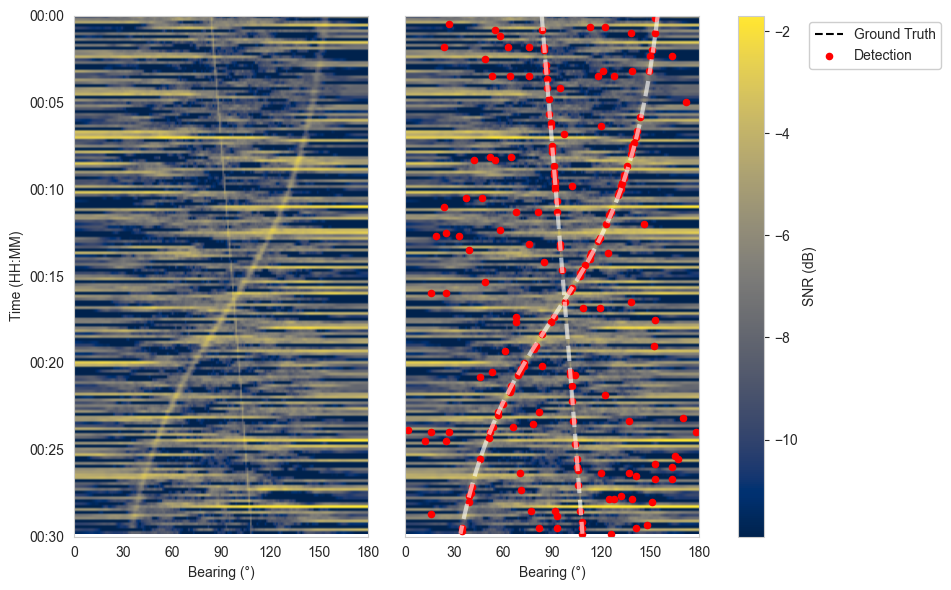

In [104]:
# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True, tight_layout=True)

# Instantiate the plotter
style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide)

# --- Left Plot: Raw SNR ---
plotter.plot_snr(
    snr_array=snr_array,
    timesteps=config.time.timesteps,
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)

# --- Right Plot: SNR with Detections & Truth ---
_, im = plotter.plot_snr(
    snr_array=snr_array,
    timesteps=config.time.timesteps,
    all_detections=all_detections,
    truths=source_truths['bearing_truths'],
    ax=axs[1],
    add_colorbar=False # We will add the colorbar manually below
)
axs[1].set_ylabel("") # Remove the duplicate y-axis label

# --- Add a single, shared colorbar ---
fig.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

plt.show()

## 4. Target Tracking with a Kalman Filter & JPDA

With our detections ready, it's time to perform the final stage: tracking. The goal is to take our noisy, ambiguous bearing measurements and produce clean, estimated paths for each target.

Our tracker is built from several key components:

* **The Filter**: A Kalman filter is used to predict and update the state (bearing and bearing rate) of each track.
* **The Hypothesiser (JPDA)**: For each detection, the Joint Probabilistic Data Association (JPDA) hypothesiser calculates the probability that it originated from each track versus being a false alarm (clutter).
* **Probabilities**: To perform this statistical reasoning, we need to provide the tracker with some information about the environment, namely the **Probability of Detection ($P_D$)** and the **Probability of False Alarm ($P_{FA}$)**.

#### 4.1 Defining the State-Space Models

We first define two fundamental models that describe the physics of our tracking problem:

* `transition_model`: This is the physics model that the Kalman filter uses to predict a target's future state based on its current state. We use a `NearlyConstantVelocity1 model, which assumes that a target's bearing-rate will remain roughly constant between time steps, with some small, random "process noise" to account for uncertainty and unmodelled dynamics.

* `measurement_model`: This model defines the mathematical relationship between the target's internal state (e.g., its bearing and bearing rate) and what our sensor can actually measure (in this case, only bearing).

In [105]:
# --- 1. Define the core state-space models ---

# The transition model describes the physics of target motion
transition_model = CombinedLinearGaussianTransitionModel(
    [NearlyConstantVelocity(
        config.filter.process_noise_std**2, config.time.time_interval)
    ]
)

# The measurement model describes how a state is perceived by the sensor
measurement_model = LinearGaussianMeasurementModel(
    noise_covar=np.diag([config.filter.measurement_noise_rad**2]),
    mapping=config.filter.state_mapping,
    ndim_state=config.filter.ndim_state
)


#### 4.2 Calculating the Statistical Probabilities

We can incorporate an understanding of the statistical nature of the environment to better reason about detections and track associations. We provide this information by calculating two key probabilities:

*   **Probability of False Alarm ($P_{FA}$)**: This is the probability that a detection is not from a real target, but is instead just a random instance of noise that happened to cross our detection threshold. This probability is governed by the `threshold_factor` (alpha) set in our `CFARDetector`. The detector's rule is:
    
    `Total Power > threshold_factor * Estimated Noise Power`
    
    Since `Total Power = Signal Power + Noise Power`, we can determine the implicit Signal-to-Noise Ratio (SNR) threshold:
    
    `Signal Power / Noise Power > threshold_factor - 1`
    
    Therefore, the SNR threshold is `threshold_factor - 1`. We calculate the $P_{FA}$ that corresponds to this SNR threshold.

* **Probability of Detection ($P_{D}$)**: This is the probability that a real target will actually be detection by our sensor at any given time steo. This depends on the target's estimated SNR.

In [106]:
# --- 2. Calculate the statistical probabilities for the tracker ---

# Calculate the probability of a false alarm from the SNR threshold
snr_threshold_db = 10 * np.log10(config.detection.threshold_factor - 1)
p_fa = p_fa_from_snr_thresh(snr_threshold_db)

# Calculate the probability of detection for each target individually
p_d_per_target = []
for i, src in enumerate(config.sources):
    # Use the average transmission loss for a stable estimate
    avg_tloss = np.mean(tloss_array[:, i])

    # Estimate the average received SNR for this target
    estimated_snr = (
        np.max(src.source_level_db)  # Use max SL if it's a list
        - avg_tloss
        - config.signal.noise_level_db
        + config.platform.array_gain
    )

    # Calculate Pd using the Rayleigh distribution assumption for noise
    p_d_per_target.append(p_d_rayleigh(estimated_snr, p_fa))

print(f"Calculated P_FA: {p_fa:.2e}")
print(f"Estimated P_D per target: {[round(p, 2) for p in p_d_per_target]}")

Calculated P_FA: 6.07e-01
Estimated P_D per target: [np.float64(0.64), np.float64(0.65)]


#### 4.3 Initialising the Hypothesiser

We will use the **Joint Probabilistic Data Association (JPDA)** hypothesiser to determine how to associate
detections to tracks. When a new set of detections arrives, the JPDA's job is to calculate a probability for every possible scenario. For example, it will determine:

* The probability that Detection 1 belongs to Track 1.
* The probability that Detection 1 belongs to Track 2
* The probability that Detection 1 is just a false alarm.

It does this for all detections and all tracks, creating a potentially complex web of associations. This allows the filter to perform a "weighted" update, considering all possibilities instead of making a single, hard decision about which detection belongs to which track. 

We can also enable Efficient Hypothesis Management (EHM) to reduce computation time in scenarios with many tracks and detections.

In [107]:
# --- 3. Initialise the JPDA Hypothesiser ---

hypothesiser = JPDAHypothesiser(
    measurement_model=measurement_model,
    detection_probability=p_d_per_target,
    gate_probability=config.filter.gate_probability,
    use_ehm=True  # Enable Efficient Hypothesis Management (EHM) for better performance
)

print("JPDA Hypothesiser initialised successfully.")

JPDA Hypothesiser initialised successfully.


#### 4.4 Initiating Tracks

Before the tracker can start processing detections, it needs to know what it's looking for. This process is called **track initiation**.

In a real-world system, tracks would be created automatically by a "track initiator" algorithm that looks for patterns in the detection data. However, for simplicitly, we can "cheat" by using the ground truth to create a perfect set of initial tracks.

Starting the tracker this way allows us to specifically test its ability to **follow** targets and **handle data association**, without worrying about the separate challenge of track initiation.

In [108]:
# --- 4. Initialise Tracks from Ground Truth ---

# In a simulation, we can "cheat" and start our tracks perfectly.
initial_tracks = set()
for id, truth in enumerate(source_truths["bearing_truths"]):
    initial_tracks.add(
        Track(
            [
                GaussianState(
                    mean=truth[0].state_vector,
                    covar=np.diag(config.filter.init_cov_diag_rad) ** 2,
                    timestamp=truth[0].timestamp,
                )
            ],
            id=id,
        )
    )


#### 4.5 Building and Running the Multi-Target Tracker

With all the individual components now defined and configured, the final step is to assemble into the main `MultiTargetTracker` object and run the simulation.

The `MultiTargetTracker` class acts as the central orchestrator. We provide it with all our previously defined components:

* The transition and measurement models.
* The Kalman predictor and updater.
* The JPDA hypothesiser.
* The set of initial tracks.

Once initialised, we simply loop through our list of detections. At each time step, we call the tracker's `.update()` method, feeding it the new set of measurements. This single command triggers the entire predict-associate-update cycle, advancing the tracks one step at a time. After processing all detections, we retrieve the final, updated tracks from the tracker.

In [109]:
# --- 5. Assemble and run the tracker ---

tracker = MultiTargetTracker(
    tracks=initial_tracks,
    transition_model=transition_model,
    measurement_model=measurement_model,
    predictor=KalmanPredictor(transition_model),
    updater=GaussianMixtureKalmanUpdater(measurement_model),
    hypothesiser=hypothesiser,
    time_interval=config.time.time_interval,
)

# --- Execute the tracker over all timesteps ---
print("Tracking detections...")
for measurement_set in tqdm(all_detections, desc="Tracking"):
    tracker.update(measurement_set)

# --- Retrieve the final tracks ---
final_tracks = tracker.get_tracks()
print("\nTracker finished.")

Tracking detections...


Tracking:   0%|          | 0/180 [00:00<?, ?it/s]


Tracker finished.


## 5. Visualising the Tracking Results

Finally, let's visualise the final set of tracks produced by the tracker.

We will use the `BearingPlotter`'s `.animate()` method, which renders a video showing:

* **Ground Truth (Solid Lines)**: The ground truth paths of the targets.

* **Detection (Purple Circles)**: The noisy measurements that the tracker receives at each time step.

* **Track Estimates (Dashed Lines)**: The final, filtered tracks estimated by our Kalman filter.

* **Uncertainty (Shaded Areas)**: The tracker's confidence. A smaller area indicates the tracker is very certain about the target's state, while a larger area shows higher uncertainty.

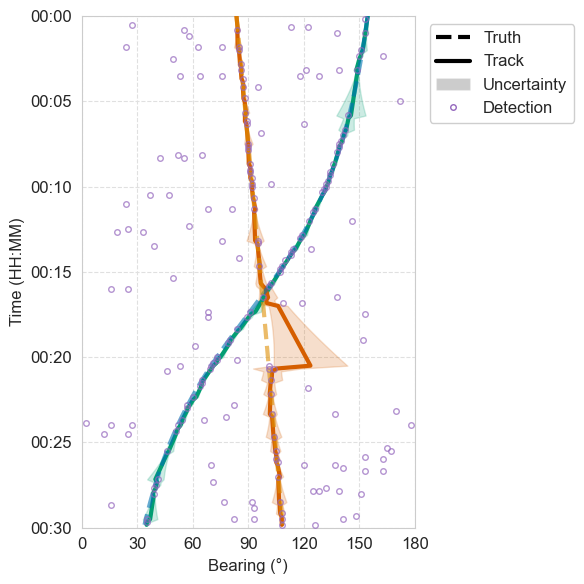

In [111]:
style_guide = {
    "figure": {
        "figsize": (6, 6),
        "font_size": 12
    }
}
plotter = BearingsPlotter(style_guide=style_guide)

plotter.plot(
    source_truths["bearing_truths"],
    final_tracks,
    all_detections,
    config.time.timesteps,
    mapping=config.filter.state_mapping,
    plot_uncertainty=True,
)
plotter.show()

# # Uncomment to create an interactive plot of the final tracks
# from IPython.display import HTML, display
# ax, anim = plotter.animate(
#     source_truths["bearing_truths"],
#     final_tracks,
#     all_detections,
#     config.time.timesteps,
#     mapping=config.filter.state_mapping,
#     plot_uncertainty=True,
# )
# display(HTML(anim.to_jshtml()))
# plt.close(ax.get_figure())